In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
from pathlib import Path

In [10]:
braindino_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/braindino').glob('run*'))
cp_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/continued_pretraining').glob('run*'))
ssl_finetune_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_intermediate').glob('run*'))
dinov3_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/dinov3').glob('run*'))


In [8]:
print(parse_metrics(dinov3_runs))

NotADirectoryError: [Errno 20] Not a directory: '/common/ganesanv/tlab/runs/adni_benchmark/dinov3/run_summary.json/run_summary.json'

In [3]:
import json
def parse_metrics(runs_paths):
    aurocs = []
    f1s = []
    for path in list(runs_paths):
        with open(path / 'run_summary.json', 'r') as f:
            d = json.load(f)

            aurocs.append(d['metrics']['test']['auroc'])
            f1s.append(d['metrics']['test']['f1'])
    return aurocs, f1s

print(parse_metrics(braindino_runs))

([0.7712022367194781, 0.7894920782851818, 0.7868126747437093, 0.8041705498602051, 0.7809878844361603, 0.7879776328052192], [0.6578947368421053, 0.6792452830188679, 0.6748466257668712, 0.6787878787878788, 0.6756756756756757, 0.6578947368421053])


In [11]:
bd_aurocs, bd_f1s = parse_metrics(braindino_runs)
cp_aurocs, cp_f1s = parse_metrics(cp_runs)
ssl_aurocs, ssl_f1s = parse_metrics(ssl_finetune_runs)
dinov3_aurocs, dinov3_f1s = parse_metrics(dinov3_runs)

df = pd.DataFrame(columns=["metric", "method", "value"])

df["method"] = ((["BrainDINO"] * len(bd_aurocs)) + (["Extended Pre-Training"] * len(cp_aurocs)) + (["3-D Aware Fine Tuning"] * len(ssl_aurocs)) + (["DINOv3"] * len(dinov3_aurocs))) * 2

df["metric"] = (["AUROC"] * (len(bd_aurocs) + len(cp_aurocs) + len(ssl_aurocs) + len(dinov3_aurocs))) + (["F1"] * (len(bd_aurocs) + len(cp_aurocs) + len(ssl_aurocs) + len(dinov3_aurocs)))

df['value'] = bd_aurocs + cp_aurocs + ssl_aurocs + dinov3_aurocs + bd_f1s + cp_f1s + ssl_f1s + dinov3_f1s


In [12]:
import itertools

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AUROC_3-D Aware Fine Tuning vs. AUROC_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01
AUROC_BrainDINO vs. AUROC_3-D Aware Fine Tuning: Mann-Whitney-Wilcoxon test two-sided, P_val:1.515e-02 U_stat=3.300e+01
AUROC_Extended Pre-Training vs. AUROC_DINOv3: Mann-Whitney-Wilcoxon test two-sided, P_val:4.329e-03 U_stat=3.500e+01
AUROC_3-D Aware Fine Tuning vs. AUROC_DINOv3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01
AUROC_BrainDINO vs. AUROC_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01
AUROC_BrainDINO vs. AUROC_DINOv3: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01


/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/statannotations/compat.py:926: UserWarning: cannot find group0 of pair in the group tuples: ('F1', '3-D Aware Fine Tuning') not in [('AUROC', 'BrainDINO'), ('AUROC', '3-D Aware Fine Tuning'), ('AUROC', 'Extended Pre-Training'), ('AUROC', 'DINOv3')]
  warnings.warn(msg)
/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/statannotations/compat.py:926: UserWarning: cannot find group1 of pair in the group tuples: ('F1', 'BrainDINO') not in [('AUROC', 'BrainDINO'), ('AUROC', '3-D Aware Fine Tuning'), ('AUROC', 'Extended Pre-Training'), ('AUROC', 'DINOv3')]
  warnings.warn(msg)
/home/ganesanv/.conda/envs/dinov3/lib/python3.10/site-packages/statannotations/compat.py:926: UserWarning: cannot find group1 of pair in the group tuples: ('F1', 'DINOv3') not in [('AUROC', 'BrainDINO'), ('AUROC', '3-D Aware Fine Tuning'), ('AUROC', 'Extended Pre-Training'), ('AUROC', 'DINOv3')]
  warnings.warn(msg)
/home/ganesanv/.conda/envs/d

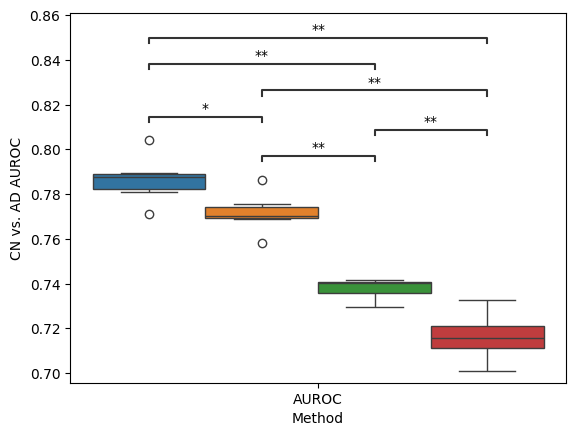

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator 

# fig, ax = plt.subplots(1, 1, tight_layout=True)
hue_order = ["BrainDINO", "3-D Aware Fine Tuning", "Extended Pre-Training", "DINOv3"]
ax = sns.boxplot(data=df, x='metric', y='value', hue='method',hue_order=hue_order, order=["AUROC"], legend=False)

methods = list(np.unique(df["method"]))
metrics = ["AUROC", "F1"]

combos = list(itertools.combinations(methods, 2))


pairs = [((metrics[i], combos[j][0]), (metrics[i], combos[j][1])) for i in range(len(metrics)) for j in range(len(combos))]

annotator = Annotator(ax, pairs, data=df, x='metric', y='value', hue='method', hue_order=hue_order, order=["AUROC"])
annotator.configure(test='Mann-Whitney', text_format='star', )
annotator.apply_and_annotate()

ax.set_xlabel('Method')
ax.set_ylabel('CN vs. AD AUROC')

plt.show()

In [ ]:
bd_50pts_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/50patients_braindino').glob('run*'))
ssl_50pts_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/50patients').glob('run*'))

In [28]:
bd_25pts_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/25patients_braindino').glob('run*'))
ssl_25pts_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/25patients').glob('run*'))

In [ ]:
bd50_aurocs, bd50_f1s = parse_metrics(bd_50pts_runs)

ssl50_aurocs, ssl50_f1s = parse_metrics(ssl_50pts_runs)
bd25_aurocs, bd25_f1s = parse_metrics(bd_25pts_runs)

ssl25_aurocs, ssl25_f1s = parse_metrics(ssl_25pts_runs)
df = pd.DataFrame(columns=["metric", "method", "value", "patients"])

df["method"] = ((["BrainDINO"] * len(bd50_aurocs))  + (["3-D Aware Fine Tuning"] * len(ssl50_aurocs))) * 2


df['value'] = bd50_aurocs + ssl50_aurocs + bd25_aurocs + ssl25_aurocs
df['patients'] = (["50"] * len(bd50_aurocs) * 2) + ((["25"] * len(bd50_aurocs) * 2))



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

50_BrainDINO vs. 50_3-D Aware Fine Tuning: Mann-Whitney-Wilcoxon test two-sided, P_val:1.515e-02 U_stat=3.000e+00
25_BrainDINO vs. 25_3-D Aware Fine Tuning: Mann-Whitney-Wilcoxon test two-sided, P_val:8.182e-01 U_stat=1.600e+01


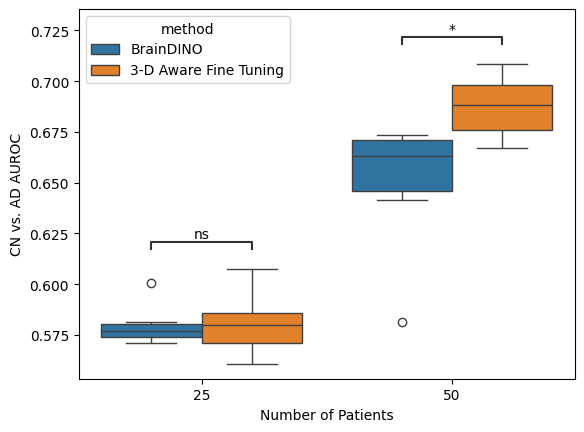

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator 

# fig, ax = plt.subplots(1, 1, tight_layout=True)
hue_order = ["BrainDINO", "3-D Aware Fine Tuning"]
ax = sns.boxplot(data=df, x='patients', y='value', hue='method',hue_order=hue_order, order=["25", "50"], )

methods = list(np.unique(df["method"]))
patients = ["25", "50"]

combos = list(itertools.combinations(methods, 2))


pairs = [((patients[i], combos[j][0]), (patients[i], combos[j][1])) for i in range(len(patients)) for j in range(len(combos))]

annotator = Annotator(ax, pairs, data=df, x='patients', y='value', hue='method', hue_order=hue_order, order=["25", "50"])
annotator.configure(test='Mann-Whitney', text_format='star', )
annotator.apply_and_annotate()

ax.set_xlabel('Number of Patients')
ax.set_ylabel('CN vs. AD AUROC')

plt.show()

In [39]:
ckpt_1499 = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_1499').glob('run*'))
ckpt_2999 = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_intermediate').glob('run*'))
ckpt_5499 = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_bad').glob('run*'))
ckpt_3999 = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_bad').glob('run*'))
ckpt_10999 = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune').glob('run*'))

ckpts = [ckpt_1499, ckpt_2999, ckpt_5499, ckpt_3999, ckpt_10999]
iter_idxs = [1499, 2999, 5499, 3999, 10999]

In [40]:
df2 = pd.DataFrame(columns=["iter", "auroc"])

iters = []
aurocs = []

for i, ckpt in enumerate(ckpts):
    a, _ = parse_metrics(ckpt)
    its = iter_idxs[i]

    aurocs.extend(a)
    iters.extend(([its] * len(a)))

df2["iter"] = iters
df2["auroc"] = aurocs

In [ ]:
fig, ax = plt.subplots(1, 1, tight_layout=True)

